# BIEN 514 Homework 3

In [203]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

In [153]:
data_0p5 = pd.read_csv('Walk_0p5micron.csv')
data_1 = pd.read_csv('Walk_1micron.csv')

## Calculate MSD (Part A)

In [240]:
def msd(data):
    """
    calculate msd for each particle in 2D

    Parameters
    ----------
        data: random walk data
    """
    t = data['t'][1:]
    data = data.iloc[:, 1:]
    
    rows = []

    for l in range(1, data.shape[0]): # for lag time (l*t)...
        sq_disp = (data[l:].reset_index(drop=True) - data[0:-l])**2 # calculate square disp.

        x = sq_disp.iloc[:, ::2] # subset x square disp.
        y = sq_disp.iloc[:, 1::2] # subset y square disp.

        avg = (x.values + y.values).mean(axis=0) # 2D MSD

        rows.append(avg)

    results = pd.DataFrame(rows, 
                           index=t,
                           columns=range(100)) # complete MSD, index indicates lag
    
    return results

In [251]:
msd_0p5 = msd(data_0p5)
msd_1 = msd(data_1)

In [252]:
eavg_0p5 = msd_0p5.mean(axis=1)
eavg_1 = msd_1.mean(axis=1)

## Fit Curve (Part B)

In [ ]:
def func(t, D, a): # N = 2
    return 4*D*(t**a)

sample_min = 30 # only use lag times with at least 30 samples per particle

popt_0p5, pcov_0p5 = curve_fit(func, eavg_0p5.index[:-sample_min], eavg_0p5[:-sample_min]) # curve fit 0.5 micron
popt_1, pcov_1 = curve_fit(func, eavg_1.index[:-sample_min], eavg_1[:-sample_min]) # curve fit 1 micron

fit_0p5 = func(eavg_0p5.index, popt_0p5[0], popt_0p5[1])
fit_1 = func(eavg_1.index, popt_1[0], popt_1[1])

In [524]:
popt_1

array([0.44995825, 0.99226117])

In [ ]:
def viscosity(D, d):
    '''
    calculate viscosity from diffusion coefficient
    
    Parameters
    ----------
        D: diffusion coefficient calculated from curve fit
        d: particle diameter in microns
    
    '''

    kB = 1.380649e-23
    T = 298
    r = (d/2) * 1e-6
    D = D * 1e-12

    return (kB * T) / (6 * np.pi * r * D)

visc_0p5 = viscosity(popt_0p5[0], 0.5) # 0.979 mPa*s
visc_1 = viscosity(popt_1[0], 1) # 0.970 mPa*s

## Plotting MSD (Part C)

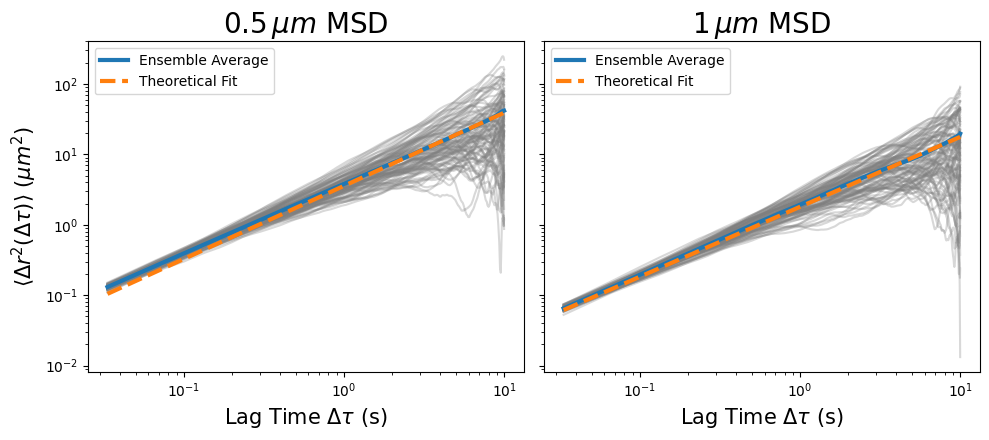

In [387]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True,)

for i in range(100):
    ax[0].plot(msd_0p5[i], color='tab:gray', alpha=0.3)
    ax[1].plot(msd_1[i], color='tab:gray', alpha=0.3)
    

ax[0].plot(eavg_0p5, color='tab:blue', linewidth=3, label='Ensemble Average')
ax[1].plot(eavg_1, color='tab:blue', linewidth=3, label='Ensemble Average')
ax[0].plot(eavg_0p5.index, fit_0p5, color='tab:orange', linewidth=3, linestyle='--', label='Theoretical Fit')
ax[1].plot(eavg_1.index, fit_1, color='tab:orange', linewidth=3, linestyle='--', label='Theoretical Fit')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[0].set_xlabel(r'Lag Time $\Delta\tau$ (s)', size=15)
ax[1].set_xlabel(r'Lag Time $\Delta\tau$ (s)', size=15)
ax[0].set_ylabel(r'$\langle \Delta r^2(\Delta\tau) \rangle$ $(\mu m^2)$', size=15)

ax[0].legend()
ax[1].legend()

ax[0].set_title(r'$0.5 \, \mu m$ MSD', size=20)
ax[1].set_title(r'$1 \, \mu m$ MSD', size=20)

fig.tight_layout()
fig.savefig('MSD.jpg', dpi=300)

## Scaling MSD by Particle Size (Part D)

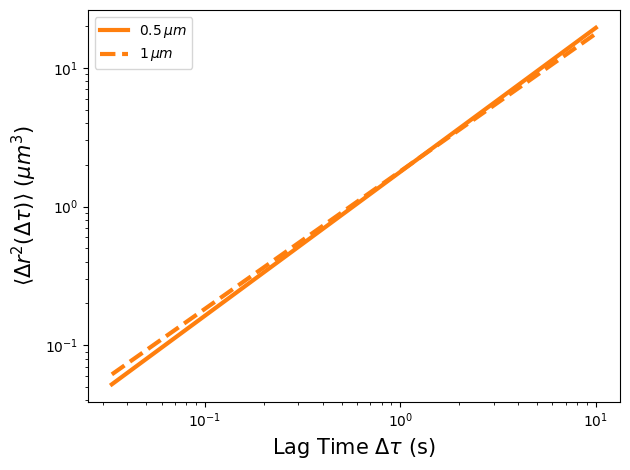

In [373]:
fit_0p5 = func(eavg_0p5.index, popt_0p5[0], popt_0p5[1])
fit_1 = func(eavg_1.index, popt_1[0], popt_1[1])

plt.plot(eavg_0p5.index, 0.5 * fit_0p5, color='tab:orange', linewidth=3, label=r'$0.5 \, \mu m$')
plt.plot(eavg_1.index, fit_1, color='tab:orange', linestyle='--', linewidth=3, label=r'$1\, \mu m$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Lag Time $\Delta\tau$ (s)', size=15)
plt.ylabel(r'$\langle \Delta r^2(\Delta\tau) \rangle$ $(\mu m^3)$', size=15)
plt.legend()
plt.tight_layout()
plt.savefig('scaled.jpg', dpi=300)

# Step Histograms + Van Hove (Part E)

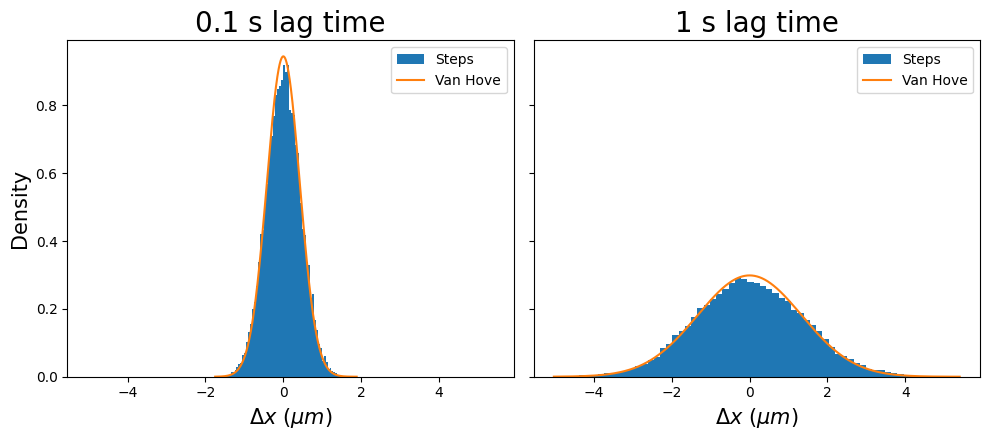

In [522]:
def steps(data, lag, ax):

    l = round(lag / 0.033)
    disp = data[l:].reset_index(drop=True) - data[0:-l]
    steps = disp.iloc[:, 1::2].values.flatten()

    x = np.linspace(steps.min(), steps.max(), 1000)
    D = popt_0p5[0]
    pdf = np.exp(-(x**2 / (4*D*lag))) / np.sqrt(np.pi*4*D*lag)
    

    ax.hist(steps, bins='scott', density=True, label='Steps')
    ax.plot(x, pdf, label='Van Hove')
    ax.legend()
    ax.set_xlabel(r'$\Delta x$ $(\mu m)$', size=15)

    
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

steps(data_0p5, 0.1, ax[0])
steps(data_0p5, 1, ax[1])

ax[0].set_ylabel('Density', size=15)
ax[0].set_title('0.1 s lag time', size=20)
ax[1].set_title('1 s lag time', size=20)
fig.tight_layout()

fig.savefig('van hove.jpg', dpi=300)
